# 07 - LSTM Model

**Approach:**
- 3-class moneyness target (ATM/OTM5/OTM10) -- consistent with 06b
- Time-based train/test split (no random sampling)
- Class weights for imbalance
- Bidirectional LSTM with temporal attention

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {device}")

Device: mps


## 1. Load and Prepare Data

In [2]:
data = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
data['decision_date'] = pd.to_datetime(data['decision_date'])
data = data.sort_values(['symbol', 'decision_date']).reset_index(drop=True)

# 3-class moneyness target (consistent with 06b)
data['moneyness'] = data['best_bucket'].str.extract(r'(ATM|OTM5|OTM10)')[0]
moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}
data['label_3'] = data['moneyness'].map(moneyness_map)

# Feature pruning (same as 06b)
drop_features = ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']
exclude_cols = ['symbol', 'decision_date', 'year_month', 'label', 'best_bucket',
                'best_return', 'fiscalDateEnding', 'year', 'label_3', 'moneyness']

feature_cols = [c for c in data.columns if c not in exclude_cols and c not in drop_features]
data[feature_cols] = data[feature_cols].fillna(data[feature_cols].median())

print(f"Data: {data.shape[0]} rows, {len(feature_cols)} features")
print(f"\n3-class distribution:")
for label, name in enumerate(['ATM', 'OTM5', 'OTM10']):
    count = (data['label_3'] == label).sum()
    print(f"  {label} ({name}): {count} ({count/len(data)*100:.1f}%)")

Data: 1391 rows, 25 features

3-class distribution:
  0 (ATM): 685 (49.2%)
  1 (OTM5): 362 (26.0%)
  2 (OTM10): 344 (24.7%)


## 2. Time-Based Split

Train on data before mid-2022, test on 2022-2025. Same split date as 06b.

In [3]:
# Time-based split at 80th percentile date
data['year'] = data['decision_date'].dt.year
unique_dates = data['decision_date'].sort_values().unique()
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_data = data[data['decision_date'] < split_date].copy()
test_data = data[data['decision_date'] >= split_date].copy()

print(f"Split date: {pd.Timestamp(split_date).date()}")
print(f"Train: {len(train_data)} rows ({train_data['decision_date'].min().date()} to {train_data['decision_date'].max().date()})")
print(f"Test:  {len(test_data)} rows ({test_data['decision_date'].min().date()} to {test_data['decision_date'].max().date()})")

Split date: 2022-06-30
Train: 1012 rows (2008-02-29 to 2022-05-31)
Test:  379 rows (2022-06-30 to 2025-12-31)


## 3. Create Sequences

In [4]:
def create_sequences_temporal(data, feature_cols, target_col, seq_length):
    """Create sequences maintaining temporal order per ticker."""
    X_seq, y_seq, dates = [], [], []
    for symbol in data['symbol'].unique():
        sym_data = data[data['symbol'] == symbol].sort_values('decision_date')
        features = sym_data[feature_cols].values
        labels = sym_data[target_col].values
        dt = sym_data['decision_date'].values
        for i in range(seq_length, len(sym_data)):
            X_seq.append(features[i-seq_length:i])
            y_seq.append(labels[i])
            dates.append(dt[i])
    return np.array(X_seq), np.array(y_seq), np.array(dates)

SEQ_LENGTH = 3  # best from prior analysis

# Create sequences from ALL data, then split by date
X_all, y_all, dates_all = create_sequences_temporal(data, feature_cols, 'label_3', SEQ_LENGTH)

# Time-based split on sequences
train_mask = dates_all < split_date
test_mask = dates_all >= split_date

X_train_raw = X_all[train_mask]
X_test_raw = X_all[test_mask]
y_train = y_all[train_mask]
y_test = y_all[test_mask]
dates_test = dates_all[test_mask]

# Scale using ONLY training data (no leakage)
n_train, seq_len, n_feat = X_train_raw.shape
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
X_test_sc = scaler.transform(X_test_raw.reshape(-1, n_feat)).reshape(len(X_test_raw), seq_len, n_feat)

print(f"Sequences: {X_all.shape}")
print(f"Train: {len(X_train_raw)} sequences ({pd.Timestamp(dates_all[train_mask][-1]).date()})")
print(f"Test:  {len(X_test_raw)} sequences ({pd.Timestamp(dates_test[0]).date()} to {pd.Timestamp(dates_test[-1]).date()})")
print(f"\nTrain label dist: {np.bincount(y_train)}")
print(f"Test label dist:  {np.bincount(y_test)}")

Sequences: (1361, 3, 25)
Train: 985 sequences (2022-05-31)
Test:  376 sequences (2022-06-30 to 2025-12-31)

Train label dist: [517 281 187]
Test label dist:  [160  69 147]


## 4. LSTM with Temporal Attention

In [5]:
class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=True):
        super().__init__()
        self.directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_out_size = hidden_size * self.directions

        self.attention = nn.Sequential(
            nn.Linear(lstm_out_size, lstm_out_size // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_size // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        return self.classifier(context)

print("AttentionLSTM defined")

AttentionLSTM defined


## 5. Training Utilities

In [6]:
def train_lstm(X_train_sc, X_test_sc, y_train, y_test, num_classes,
               hidden_size=32, num_layers=1, dropout=0.4, lr=0.001,
               epochs=150, patience=20, verbose=True):

    train_ds = TensorDataset(torch.FloatTensor(X_train_sc), torch.LongTensor(y_train))
    test_ds = TensorDataset(torch.FloatTensor(X_test_sc), torch.LongTensor(y_test))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    model = AttentionLSTM(
        input_size=X_train_sc.shape[2], hidden_size=hidden_size,
        num_layers=num_layers, num_classes=num_classes, dropout=dropout
    ).to(device)

    # Class weights from training data
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.sum() * num_classes
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(weights).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1, best_state, wait = 0, None, 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_acc'].append(correct / total)

        model.eval()
        val_loss, preds, labels = 0, [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(yb.cpu().numpy())
        preds, labels = np.array(preds), np.array(labels)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(accuracy_score(labels, preds))
        history['val_f1'].append(f1_score(labels, preds, average='macro'))

        if history['val_f1'][-1] > best_f1:
            best_f1 = history['val_f1'][-1]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if verbose and ((epoch+1) % 25 == 0 or epoch == 0):
            print(f"  Epoch {epoch+1:3d} | TrainAcc={history['train_acc'][-1]:.3f} | "
                  f"ValAcc={history['val_acc'][-1]:.3f} | ValF1={history['val_f1'][-1]:.3f}")

        if wait >= patience:
            if verbose: print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds.extend(model(xb).argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())

    return model, np.array(preds), np.array(labels), best_f1, history

print("Training utilities defined")

Training utilities defined


## 6. Train 3-Class Moneyness Model

In [7]:
print("Training 3-class moneyness LSTM (time-split)...")
model_3, preds_3, labels_3, f1_3, hist_3 = train_lstm(
    X_train_sc, X_test_sc, y_train, y_test, num_classes=3,
    hidden_size=32, num_layers=1, dropout=0.4, lr=0.001,
    epochs=150, patience=20, verbose=True
)

acc_3 = accuracy_score(labels_3, preds_3)
f1m_3 = f1_score(labels_3, preds_3, average='macro')
f1w_3 = f1_score(labels_3, preds_3, average='weighted')

print(f"\n3-Class LSTM Results (Time-Split):")
print(f"  Accuracy:    {acc_3:.4f}")
print(f"  Macro F1:    {f1m_3:.4f}")
print(f"  Weighted F1: {f1w_3:.4f}")
print(classification_report(labels_3, preds_3, target_names=['ATM', 'OTM5', 'OTM10']))

Training 3-class moneyness LSTM (time-split)...


  Epoch   1 | TrainAcc=0.535 | ValAcc=0.394 | ValF1=0.230


  Epoch  25 | TrainAcc=0.715 | ValAcc=0.348 | ValF1=0.320


  Early stop at epoch 32

3-Class LSTM Results (Time-Split):
  Accuracy:    0.3750
  Macro F1:    0.3382
  Weighted F1: 0.3748
              precision    recall  f1-score   support

         ATM       0.46      0.51      0.48       160
        OTM5       0.17      0.20      0.19        69
       OTM10       0.39      0.31      0.35       147

    accuracy                           0.38       376
   macro avg       0.34      0.34      0.34       376
weighted avg       0.38      0.38      0.37       376



## 7. Training Curves

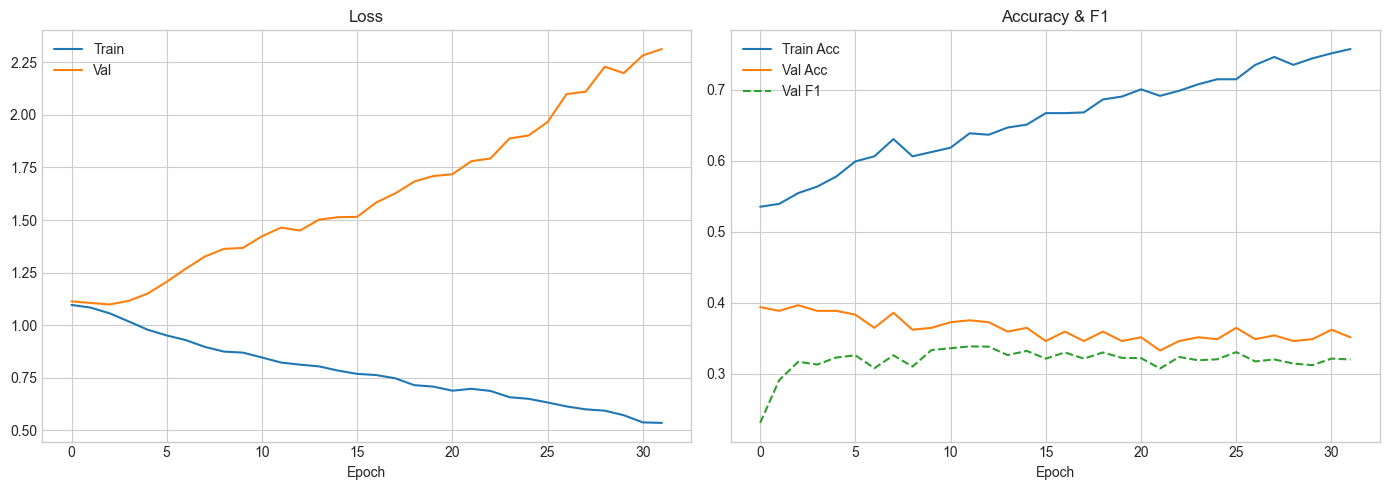

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_3['train_loss'], label='Train')
axes[0].plot(hist_3['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].set_xlabel('Epoch')
axes[1].plot(hist_3['train_acc'], label='Train Acc')
axes[1].plot(hist_3['val_acc'], label='Val Acc')
axes[1].plot(hist_3['val_f1'], label='Val F1', linestyle='--')
axes[1].set_title('Accuracy & F1')
axes[1].legend()
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_training_curves.png', dpi=150)
plt.show()

## 8. Confusion Matrix and Top-2 Accuracy

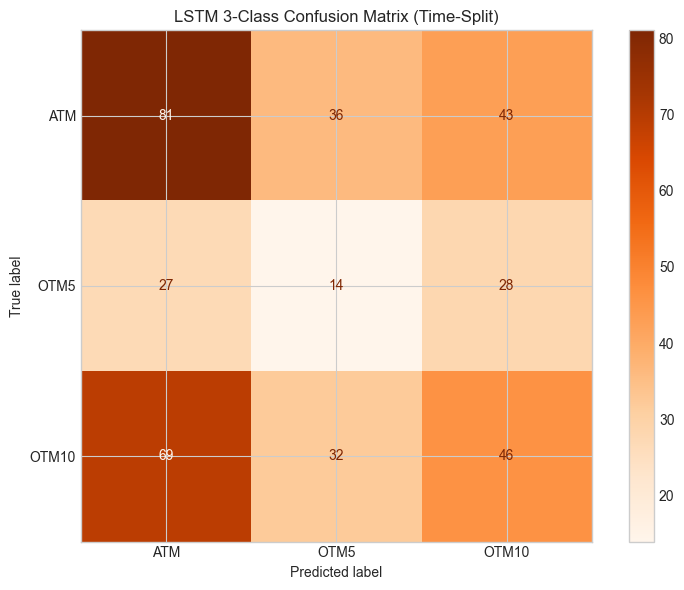

Top-1 Accuracy: 0.3750
Top-2 Accuracy: 0.6330


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(labels_3, preds_3)
disp = ConfusionMatrixDisplay(cm, display_labels=['ATM', 'OTM5', 'OTM10'])
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('LSTM 3-Class Confusion Matrix (Time-Split)')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_confusion_matrix.png', dpi=150)
plt.show()

# Top-2 accuracy
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_sc), torch.LongTensor(y_test)),
    batch_size=32, shuffle=False
)
model_3.eval()
all_proba = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model_3(xb)
        proba = torch.softmax(out, dim=1)
        all_proba.extend(proba.cpu().numpy())
all_proba = np.array(all_proba)

top2 = np.argsort(all_proba, axis=1)[:, -2:]
top2_correct = np.array([labels_3[i] in top2[i] for i in range(len(labels_3))])
print(f"Top-1 Accuracy: {acc_3:.4f}")
print(f"Top-2 Accuracy: {top2_correct.mean():.4f}")

## 9. Comparison with 06b Models

Model Comparison:
                           Model  Accuracy  Macro F1
           9-class RF (baseline)    0.3728  0.358100
          9-class XGB (baseline)    0.3871  0.355600
  6-class RF (tuned, time-split)    0.2850  0.226100
 6-class XGB (tuned, time-split)    0.2401  0.192800
6-class LGBM (tuned, time-split)    0.2164  0.176500
  6-class Two-Stage (time-split)    0.2296  0.166700
       LSTM 3-class (time-split)    0.3750  0.338209


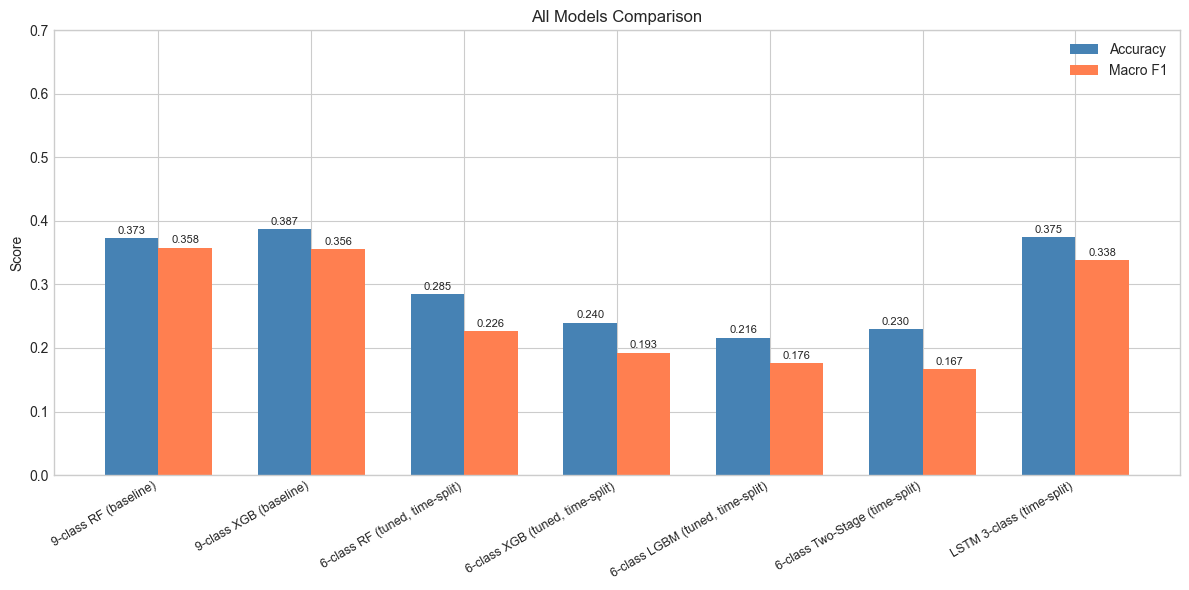

In [10]:
# Load 06b walk-forward results
try:
    prev = pd.read_csv(PROCESSED / 'improved_results.csv')
except:
    prev = pd.DataFrame()

# LSTM results
lstm_row = pd.DataFrame({
    'Model': ['LSTM 3-class (time-split)'],
    'Accuracy': [acc_3],
    'Macro F1': [f1m_3]
})

if len(prev) > 0:
    all_results = pd.concat([prev, lstm_row], ignore_index=True)
else:
    all_results = lstm_row

print("Model Comparison:")
print(all_results.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_results))
w = 0.35
b1 = ax.bar(x - w/2, all_results['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, all_results['Macro F1'], w, label='Macro F1', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('All Models Comparison')
ax.legend()
ax.set_ylim(0, 0.7)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Model

In [11]:
torch.save({
    'model_state_dict': model_3.state_dict(),
    'input_size': n_feat, 'hidden_size': 32, 'num_layers': 1,
    'num_classes': 3, 'seq_length': SEQ_LENGTH, 'feature_cols': feature_cols,
    'split_date': str(pd.Timestamp(split_date).date()),
    'approach': 'time-based split, class weights, 3-class moneyness',
}, MODELS / 'lstm_3class_moneyness.pt')

all_results.to_csv(PROCESSED / 'all_model_results.csv', index=False)

print("Model and results saved.")
print(f"\nLSTM 3-class (time-split): Acc={acc_3:.4f}, F1={f1m_3:.4f}, Top-2={top2_correct.mean():.4f}")

Model and results saved.

LSTM 3-class (time-split): Acc=0.3750, F1=0.3382, Top-2=0.6330
